In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=0.72882224/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Enter measurements for species

In [14]:
logN_dict = {'HI':'16.64, -0.01, +0.01',
            'CII':'<12.74',
            'CIII':'13.37, -0.07, +0.07',
            'CIV':'<12.86',
            'NII':'<13.52',
            'NIII':'<12.92',
            'NIV':'<12.53',
            'OII':'<12.88',
            'OIII':'13.97, -0.03, +0.03',
            #'OIV':'14.42, -0.02, +0.02',
            'NeVIII':'<13.49',
            'MgII':'<11.31',
            'AlIII':'<11.83',
            'SiII':'<12.43',
            'SiIII':'<12.42',
            'SiIV':'<12.47',
            'SIV':'<12.59',
            'SV':'<12.08',
            'SVI':'<12.90',
            'FeII':'<11.67'}

Try out a new solution including sub-solar [C/O]

In [15]:
logN_HI_test = 16.64
log_hdens_test = -2.9 #-1.7  
O_H_test = -2.6 #-1.0  
C_O_test = -0.4
N_O_test = -0.2
log_metals_test = get_metal_abundance(O_H_test, {'C': C_O_test, 'N': N_O_test})

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp, {'C': C_O_test, 'N': N_O_test})

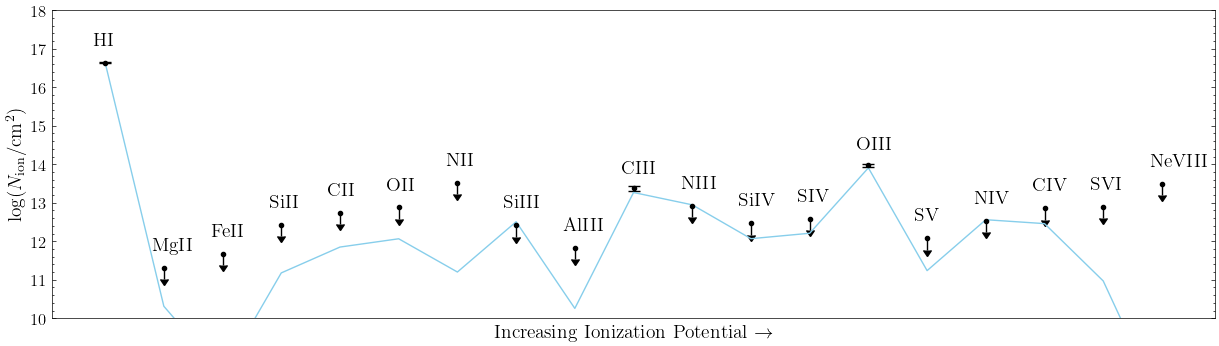

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Define overridden priors, likelihood, and posterior

In [18]:
def lambda_log_prior(params):
    
    # Only parameters being varied
    logN_HI, log_hdens, O_H, C_O, N_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, O_H, {'C': C_O, 'N': N_O}])
    
    if N_O < -3:
        return -np.inf
    
    # Call the original prior function on the full set of parameters
    return log_prior(params_full)

In [19]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    logN_HI, log_hdens, O_H, C_O, N_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, O_H, {'C': C_O, 'N': N_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [20]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Time to fit!

In [21]:
pos = np.array([logN_HI_test, log_hdens_test, O_H_test, C_O_test, N_O_test]) + 1e-6 * np.random.randn(500, 5)
nwalkers, ndim = pos.shape

In [22]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [24]:
#sampler.run_mcmc(pos, 500, progress=True);

In [25]:
#flat_samples_subsolar = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['logN_HI', 'log_hdens', '[O/H]', '[C/O]', '[N/O]'])
#flat_samples_subsolar.to_csv(savedir+'subsolar_flat.csv', index=False)

flat_samples_subsolar = pd.read_csv(savedir+'subsolar_flat.csv')

In [26]:
flat_samples_subsolar['[M/H]'] = [get_metal_abundance(flat_samples_subsolar.iloc[i]['[O/H]'], 
                                                   {'C': flat_samples_subsolar.iloc[i]['[C/O]'],
                                                    'N': flat_samples_subsolar.iloc[i]['[N/O]']}) for 
                               i in range(len(flat_samples_subsolar))]

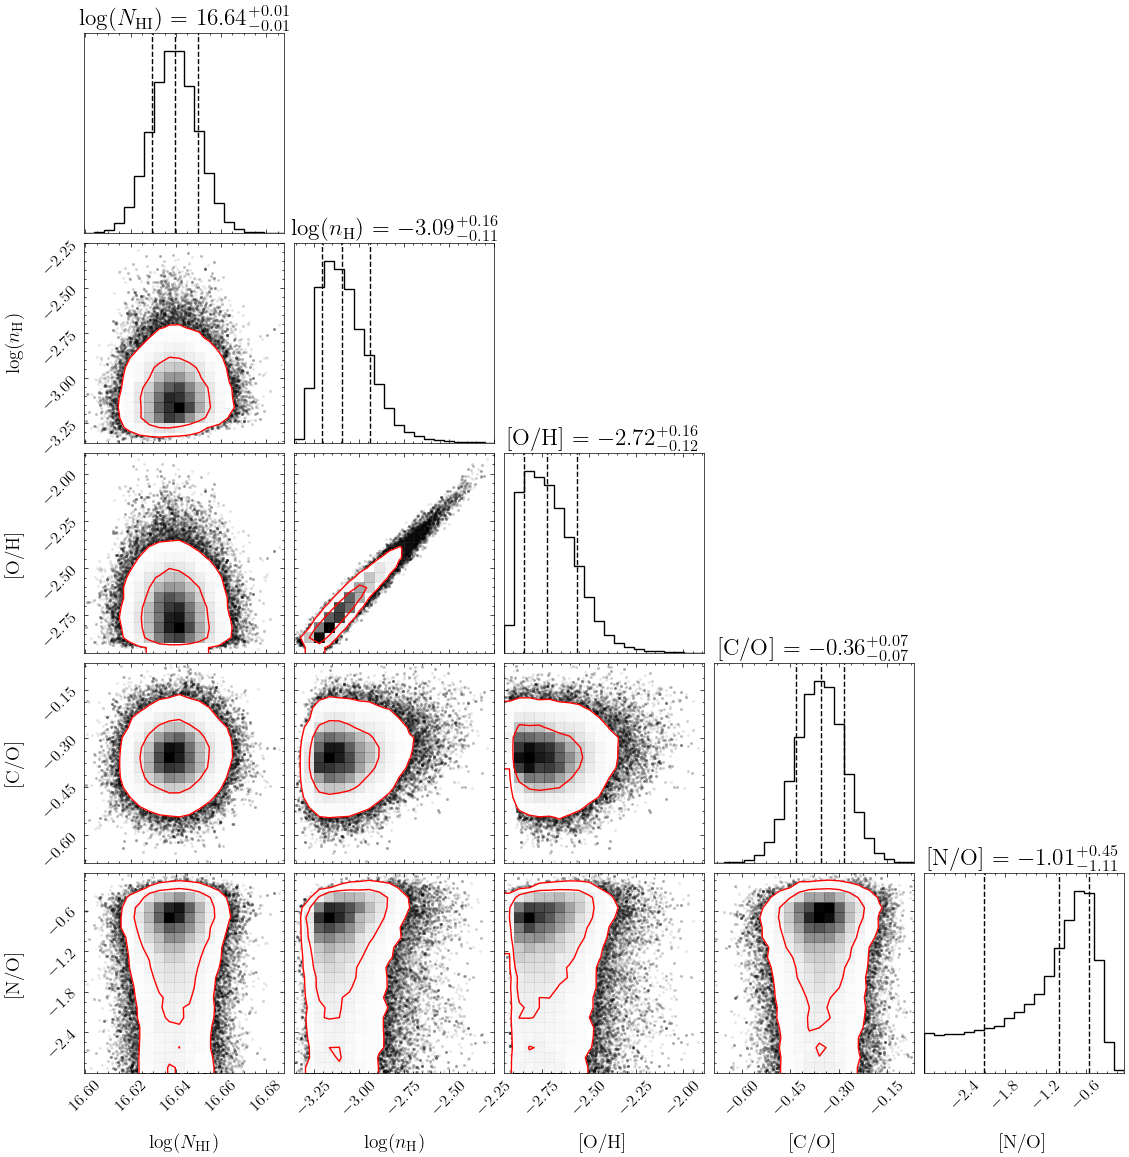

In [27]:
fig = corner.corner(
    flat_samples_subsolar.loc[:, ['logN_HI', 'log_hdens', '[O/H]', '[C/O]', '[N/O]']], 
    quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_{\mathrm{HI}})$', r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', 
            r'$[\mathrm{C/O}]$', r'$[\mathrm{N/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

(array([5.5121e+04, 5.6845e+04, 4.4875e+04, 2.6848e+04, 1.0901e+04,
        3.3570e+03, 1.4070e+03, 4.6500e+02, 1.5700e+02, 2.4000e+01]),
 array([-2.99997606, -2.89823403, -2.79649199, -2.69474996, -2.59300792,
        -2.49126589, -2.38952385, -2.28778182, -2.18603978, -2.08429775,
        -1.98255571]),
 <BarContainer object of 10 artists>)

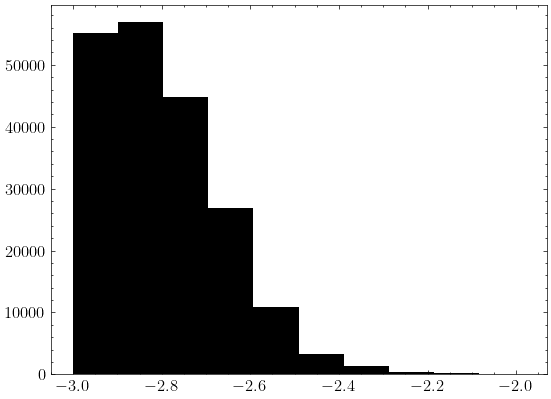

In [28]:
plt.hist(flat_samples_subsolar['[M/H]'])

In [29]:
hist, bins = np.histogram(flat_samples_subsolar['[N/O]'], bins=150, density=True)
centers = 10**(.5*(bins[1:]+bins[:-1]))

In [30]:
PDF = hist/integrate.trapz(x=centers, y=hist)

Text(0, 0.5, 'PDF')

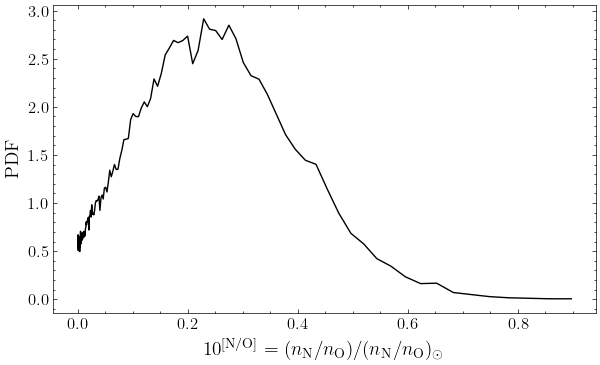

In [31]:
fig, ax = plt.subplots(1, figsize=(7, 4))

ax.plot(centers, PDF)
ax.set_xlabel(r'$10^{[\mathrm{N}/\mathrm{O}]}=(n_{\mathrm{N}}/n_{\mathrm{O}})/(n_{\mathrm{N}}/n_{\mathrm{O}})_{\odot}$')
ax.set_ylabel('PDF')

In [32]:
CDF = integrate.cumtrapz(x=centers, y=PDF, initial=0)/integrate.trapz(x=centers, y=PDF)

In [33]:
CDF_inv_interp = interpolate.interp1d(x=CDF, y=centers)

Text(0, 0.5, 'CDF')

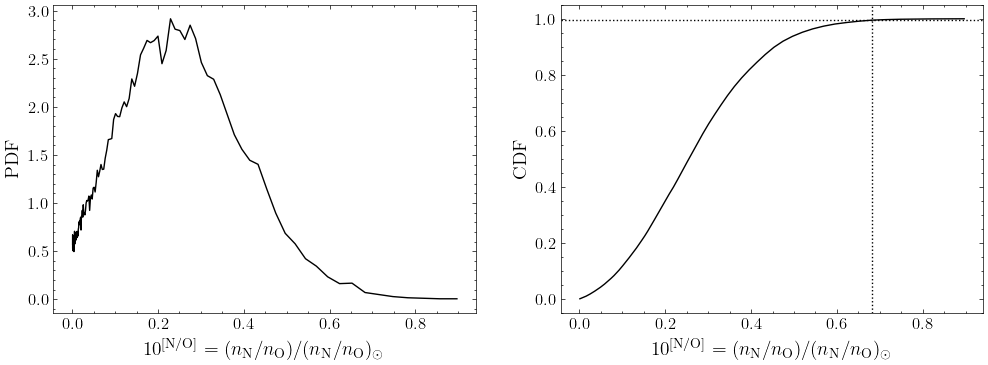

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(centers, PDF)
axes[0].set_xlabel(r'$10^{[\mathrm{N}/\mathrm{O}]}=(n_{\mathrm{N}}/n_{\mathrm{O}})/(n_{\mathrm{N}}/n_{\mathrm{O}})_{\odot}$')
axes[0].set_ylabel('PDF')

axes[1].plot(centers, CDF)
axes[1].axhline(0.995, linestyle=':')
axes[1].axvline(CDF_inv_interp(0.995), linestyle=':')
axes[1].set_xlabel(r'$10^{[\mathrm{N}/\mathrm{O}]}=(n_{\mathrm{N}}/n_{\mathrm{O}})/(n_{\mathrm{N}}/n_{\mathrm{O}})_{\odot}$')
axes[1].set_ylabel('CDF')

In [35]:
np.log10(CDF_inv_interp(0.995))

-0.16656653466924723

Overplot fit samples

In [36]:
sample_indices_subsolar = np.random.randint(low=0, high=len(flat_samples_subsolar), size=200)

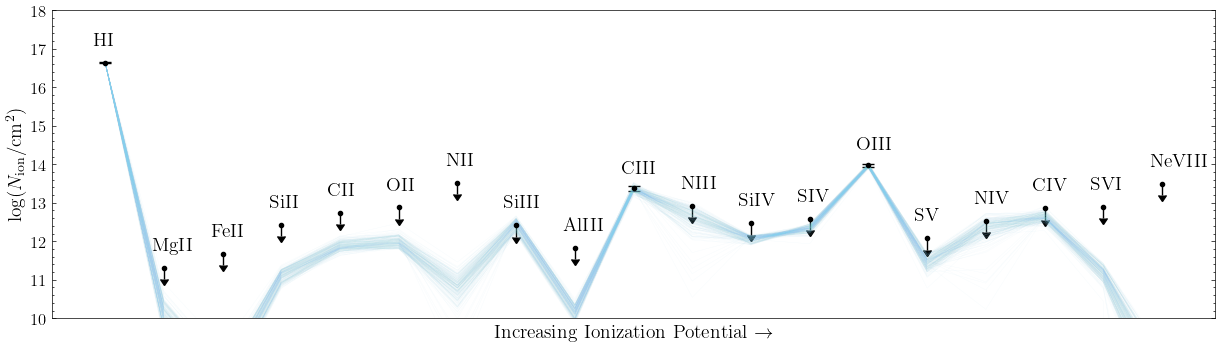

In [37]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_subsolar)):
    
    idx = sample_indices_subsolar[i]
    flat_samples_row = flat_samples_subsolar.iloc[i]
    logN_HI = flat_samples_row['logN_HI']
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['[M/H]']
    C_O = flat_samples_row['[C/O]']
    N_O = flat_samples_row['[N/O]']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI, log_hdens, 
                                         log_metals, species_logN_interp, {'C': C_O, 'N': N_O})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue', lw=.2, alpha=.1)

Plot the posterior for cloud size

In [38]:
flat_samples_subsolar['cloud_size_pc'] = (10**flat_samples_subsolar['logN_HI']/10**flat_samples_subsolar['log_hdens'])*3.24078e-19

Text(0, 0.5, 'Probability Density')

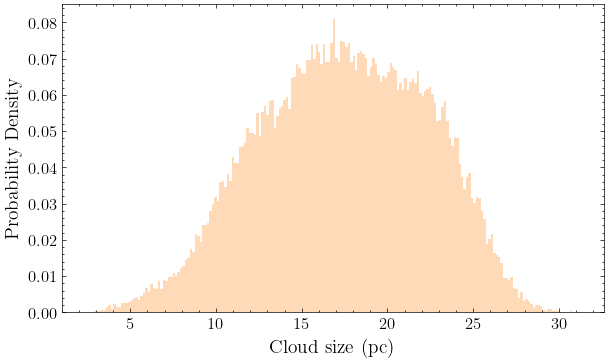

In [39]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_subsolar['cloud_size_pc'], bins=200, density=True, color='peachpuff')

ax.set_xlabel('Cloud size (pc)')
ax.set_ylabel('Probability Density')